https://github.com/RPonty/cberreteagarponty.github.io.git

**<h1>Analyzing the Impact of Political Party in Power on Stock Market Returns</h2>**
>**by:** Carlos Berreteaga and Robinne Ponty

## 1. Introduction

- **Background**: This project stems from our curiosity about the claims made by different political parties regarding their policies and their effects on stock market performance. Both parties often assert that their governance leads to better economic outcomes, but it can be challenging to discern which statements are credible. By exploring historical stock market data in relation to political leadership, we aim to uncover patterns that clarify whether there's a tangible link between the political party in power and stock market returns. Additionally, we want to incorporate inflation rates to see how they correlate with stock performance during different administrations. Furthermore, We will investigate which industries perform better under specific political parties, providing a comprehensive analysis of the relationship between political decisions and economic conditions.

- **Research Question**: How does the political party in power influence stock market returns in the United States, and how do inflation rates and industry performance factor into this relationship?

- **Objectives**:
  - To analyze historical stock market returns during different political administrations.
  - To evaluate the impact of inflation rates on stock performance.
  - To determine which industries perform better under specific political parties.

## 2. Data Collection
### 2.1 Political Party Data

Our data collection begins by scraping data on U.S. presidents from Britannica to create a structured dataset that we can analyze later in connection with economics and political power. This information is important for understanding how different political leaders affect economic outcomes, helping us explore trends in policy impacts based on party affiliation. Ultimately, this organized dataset allows for a thorough analysis of the relationship between political power and economic conditions in the U.S., enhancing our understanding of how leadership and party ideology influence economic performance over time.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import yfinance as yf
import requests
import matplotlib.pyplot as plt

In [ ]:
url = 'https://www.britannica.com/topic/Presidents-of-the-United-States-1846696'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

# Initialize lists to store the scraped data
no = [] #numerical order president 1-46
presidents = []
birthplaces = []
parties = []
terms = []


    if len(columns) >= 4:  # Make sure there are enough columns
        no.append(columns[1].text.strip())
        presidents.append(columns[2].text.strip())
        birthplaces.append(columns[3].text.strip())
        parties.append(columns[4].text.strip())
        terms.append(columns[5].text.strip())

# Create a DataFrame from the scraped data
presidents_df = pd.DataFrame({
    'No.': no,
    'President': presidents,
    'Birthplace': birthplaces,
    'Party': parties,
    'Term': terms
})

presidents_df.head()



,No.,President,Birthplace,Party,Term
0,1,George Washington,Virginia,Federalist,1789–97
1,2,John Adams,Massachusetts,Federalist,1797–1801
2,3,Thomas Jefferson,Virginia,Democratic-Republican,1801–09
3,4,James Madison,Virginia,Democratic-Republican,1809–17
4,5,James Monroe,Virginia,Democratic-Republican,1817–25


In [ ]:
#Adding in the home state of each president
#Scraping from wikipedia
url = 'https://en.wikipedia.org/wiki/List_of_presidents_of_the_United_States_by_home_state'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

president = []
home_state = []

rows = soup.find_all('tr')[1:]  # Skipping the header row

for row in rows:
    columns = row.find_all('td')

### 2.2 Stock Market Data

We utilize the yfinance module and import it to download historical data for the S&P 500 index using its ticker symbol, "^GSPC," from Yahoo Finance, starting from January 1, 1927. We then resample this data to a yearly frequency by taking the last closing price for each year. This approach helps us create a structured dataset that captures the annual performance of the S&P 500, which is crucial for analyzing long-term market trends and understanding how economic conditions impact stock market performance over time.



In [ ]:
#Grab S&P 500 data from yfinance
ticker = "^GSPC"  #SP500 ticker
sp500_data = yf.download(ticker, start="1927-01-01")

# Resample the data to yearly frequency, taking the last closing price of each year
annual_data = sp500_data['Close'].resample('YE').last()

annual_data.head()

[*********************100%***********************]  1 of 1 completed


,Close
Date,
1927-12-31,17.660000
1928-12-31,24.350000
1929-12-31,21.450001
1930-12-31,15.340000
1931-12-31,8.120000


### 2.3 Additional Data Points
- **Economic Indicators**:
  - GDP Growth Rate
  - Unemployment Rate
  - Inflation Rate
- **Market Sentiment Indicators**:
  - Consumer Confidence Index
  - Business Confidence Index
- **Monetary Policy Indicators**:
  - Interest Rates
- **Sector Performance**:
  - Sector-specific returns during different administrations.

## 3. Data Cleaning and Preparation

We begin Data Cleaning and Prepartion by processing the `Term` column in the `presidents_df` DataFrame by splitting it into `Start Year` and `End Year`. This allows us to better analyze each president's time in office.

We then define a function to convert the year values into a four-digit format, handling potential issues like missing values, special characters, and two-digit years. This ensures consistency and accuracy in our dataset. After applying this conversion function to both the `Start Year` and `End Year` columns, we update the `End Year` for each president to match the start year of the next president. For the last president, we manually set the `End Year` to 2024.

Finally, we drop the original `Term` column to streamline the dataset. This process enhances the dataset's usability for subsequent analyses of presidential terms in relation to economic and political dynamics.

In [ ]:
# Split the Term column into Start Year and End Year
presidents_df[['Start Year', 'End Year']] = presidents_df['Term'].str.split('–', expand=True)

# Function to convert to four-digit year format
def convert_year(year):
    if pd.isna(year) or year is None or year.strip() == '':
        return None
    year = year.strip()
    if year[-1] in ('*', '**'):
        year = year[:-1]  # Remove special characters
    try:
        year_int = int(year)
        # Handle two-digit years
        if year_int < 100:
            year_int += 2000 if year_int > 20 else 1900
        return f"{year_int:04d}"
    except ValueError:
        return None

# Apply the conversion function
presidents_df['Start Year'] = presidents_df['Start Year'].apply(convert_year)
presidents_df['End Year'] = presidents_df['End Year'].apply(convert_year)

# Shift the Start Year column to create the End Year based on the next president's start year
presidents_df['End Year'] = presidents_df['Start Year'].shift(-1)

# The last president's End Year should be 2024 it was showing NaN
presidents_df.iloc[-1, presidents_df.columns.get_loc('End Year')] = 2024
# Drop the original Term column
presidents_df.drop(columns=['Term'], inplace=True)

In [ ]:
presidents_df.head()

,No.,President,Birthplace,Party,Start Year,End Year
0,1,George Washington,Virginia,Federalist,1789,1797
1,2,John Adams,Massachusetts,Federalist,1797,1801
2,3,Thomas Jefferson,Virginia,Democratic-Republican,1801,1809
3,4,James Madison,Virginia,Democratic-Republican,1809,1817
4,5,James Monroe,Virginia,Democratic-Republican,1817,1825


In this step, we calculate the yearly returns for the S&P 500 index by using the percentage change of the annual closing prices. We drop any missing values to ensure a clean dataset and create a new DataFrame, `yearly_returns_df`, that contains these returns with the appropriate column name.

Next, we reset the index of this DataFrame to include the year as a separate column for easier analysis. We also convert the year from a datetime format to a string format for better readability.

Additionally, we calculate the average closing price for the S&P 500 by resampling the data to a yearly frequency and taking the mean of the closing prices. This average closing price is stored in a new DataFrame, `avg_closing_price_df`, which also has the year included as a separate column after resetting the index. This process allows us to analyze the relationship between yearly returns and average closing prices, providing valuable insights into market performance over time.

In [ ]:
# Calculate yearly returns
yearly_returns = annual_data.pct_change().dropna()  # pct_change calculates the percentage change

yearly_returns_df = pd.DataFrame(yearly_returns)
yearly_returns_df.columns = ['Yearly Return']

# Reset the index to have the year as a column
yearly_returns_df.reset_index(inplace=True)

# Convert the year from datetime to a string for easier reading
yearly_returns_df['Year'] = yearly_returns_df['Date'].dt.year

# Calculate the average closing price
avg_closing_price = sp500_data['Close'].resample('YE').mean()

# Convert the average closing price to a DataFrame
avg_closing_price_df = pd.DataFrame(avg_closing_price)
avg_closing_price_df.columns = ['Avg Closing Price']

# Reset the index to have the year as a column
avg_closing_price_df.reset_index(inplace=True)
avg_closing_price_df['Year'] = avg_closing_price_df['Date'].dt.year


In [ ]:
avg_closing_price_df.head()

,Date,Avg Closing Price,Year
0,1927-12-31,17.660000,1927
1,1928-12-31,19.937200,1928
2,1929-12-31,26.123936,1929
3,1930-12-31,21.033626,1930
4,1931-12-31,13.631071,1931


Here we are striving to calculate the average yearly returns of the S&P 500 by political party using the `merged_df` DataFrame, which contains both presidential terms and yearly returns. We group the data by the `Party` column and compute the mean of the `Yearly Return` for each political party.

After calculating the averages, we reset the index to convert the grouped data back into a DataFrame format. We also rename the columns for clarity, changing them to `Party` and `Average Yearly Return`. This organized dataset allows us to easily compare the average yearly returns associated with different political parties, contributing to our analysis of the relationship between political leadership and economic performance.

In [ ]:
# Calculate average yearly returns by political party
average_returns = merged_df.groupby('Party')['Yearly Return'].mean().reset_index()

# Rename columns
average_returns.columns = ['Party', 'Average Yearly Return']

In [ ]:
average_returns.head()

,Party,Average Yearly Return
0,Democratic,0.099025
1,Republican,0.059131


Next, we ensure that the `Start Year` and `End Year` columns in the `presidents_df` DataFrame are converted to integer format. This allows us to handle any non-numeric values more effectively by using `pd.to_numeric` with the `errors='coerce'` option, which replaces invalid entries with `NaN`. We then remove any rows that contain `NaN` values in these columns to maintain data integrity.

Following that, we create a new DataFrame that captures each year a president was in office. We iterate over each row of the cleaned `presidents_df`, extracting the start and end years for each president. For each year in that range, we create a new entry with the corresponding president's details (name, birthplace, and party).

After collecting this data, we convert the list of dictionaries into a DataFrame called `expanded_presidents_df`. Finally, we merge this new DataFrame with the `yearly_returns_df` on the `Year` column using a left join. This process enriches our dataset by linking presidential terms with yearly S&P 500 returns, facilitating further analysis of the economic impact of different presidencies.

In [ ]:
# Ensure the 'Start Year' and 'End Year' columns are integers
presidents_df['Start Year'] = pd.to_numeric(presidents_df['Start Year'], errors='coerce')
presidents_df['End Year'] = pd.to_numeric(presidents_df['End Year'], errors='coerce')

presidents_df = presidents_df.dropna(subset=['Start Year', 'End Year'])

# Create a DataFrame with each year a president was in office
expanded_presidents = []
for _, row in presidents_df.iterrows():
    start_year = int(row['Start Year'])
    end_year = int(row['End Year'])
    for year in range(start_year, end_year + 1):
        expanded_presidents.append({
            'Year': year,
            'President': row['President'],
            'Birthplace': row['Birthplace'],
            'Party': row['Party']
        }) #Note: We are keeping this as a

# Convert the list to a DataFrame
expanded_presidents_df = pd.DataFrame(expanded_presidents)

# Merge the DataFrames on the 'Year' column
merged_df = pd.merge(expanded_presidents_df, yearly_returns_df, on='Year', how='left')


In [ ]:
merged_df = merged_df[merged_df['Year'] >= 1928]
merged_df.head()

,Year,President,Birthplace,Party,Date,Yearly Return
168,1928,Calvin Coolidge,Vermont,Republican,1928-12-31,0.378822
169,1929,Calvin Coolidge,Vermont,Republican,1929-12-31,-0.119096
170,1929,Herbert Hoover,Iowa,Republican,1929-12-31,-0.119096
171,1930,Herbert Hoover,Iowa,Republican,1930-12-31,-0.284849
172,1931,Herbert Hoover,Iowa,Republican,1931-12-31,-0.470665


### 2.3 Additional Data Points
- **Economic Indicators**:
  - GDP Growth Rate
  - Unemployment Rate
  - Inflation Rate
- **Market Sentiment Indicators**:
  - Consumer Confidence Index
  - Business Confidence Index
- **Monetary Policy Indicators**:
  - Interest Rates
- **Sector Performance**:
  - Sector-specific returns during different administrations.






## 4. Exploratory Data Analysis (EDA)

We start off our EDA by createing a visual representation of the S&P 500's yearly performance and average closing prices over time using Matplotlib.

First, we set up a figure with two subplots. The first subplot displays the yearly returns of the S&P 500. We plot the years on the x-axis and the corresponding yearly returns on the y-axis, using blue markers to highlight the data points. This graph helps us observe trends in the market's performance from year to year, providing insights into how economic conditions may fluctuate.

The second subplot focuses on the average closing price of the S&P 500 by year. Here, we use green markers to plot the average closing prices, which allows us to see how the overall market valuation changes over time.

Both plots are labeled appropriately, with titles, x and y labels, and grids for better readability. The `plt.tight_layout()` function ensures that the subplots do not overlap, making the graphs clearer and easier to interpret. Finally, we display the combined plots, offering a comprehensive view of the S&P 500's performance.

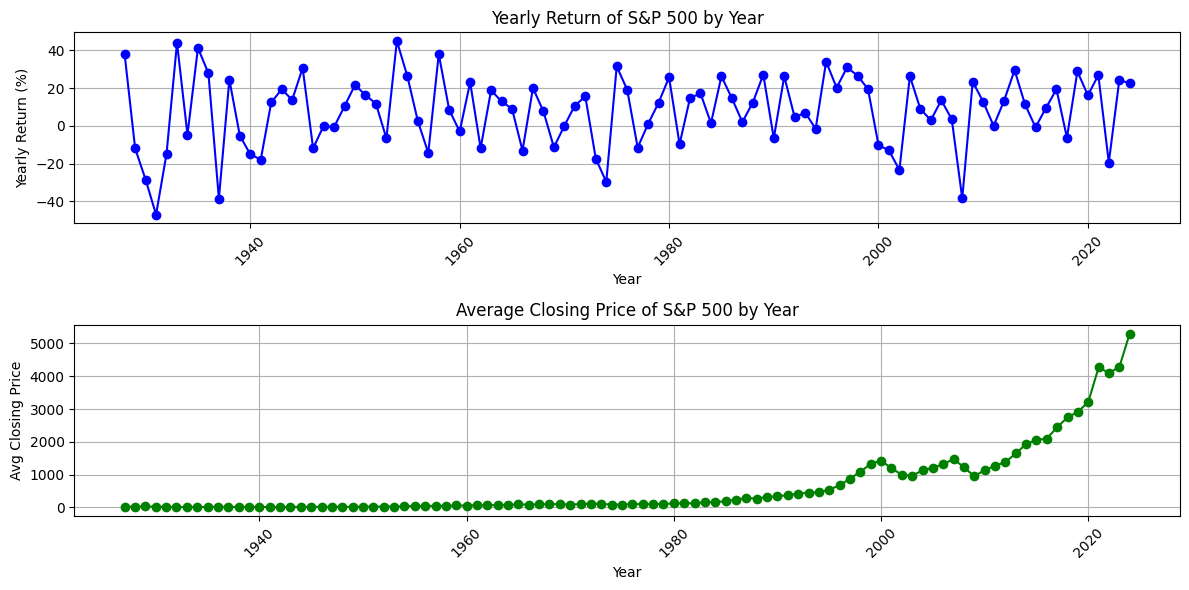

In [ ]:
#Plot the yearly returns
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)  # Create a subplot for yearly returns
plt.plot(yearly_returns_df['Year'], yearly_returns_df['Yearly Return']*100, marker='o', color='blue')
plt.title('Yearly Return of S&P 500 by Year')
plt.xlabel('Year')
plt.ylabel('Yearly Return (%)')
plt.grid()
plt.xticks(rotation=45)

#Plot the average closing price per year
plt.subplot(2, 1, 2)  # Create a subplot for average closing price
plt.plot(avg_closing_price_df['Year'], avg_closing_price_df['Avg Closing Price'], marker='o', color='green')
plt.title('Average Closing Price of S&P 500 by Year')
plt.xlabel('Year')
plt.ylabel('Avg Closing Price')
plt.grid()
plt.xticks(rotation=45)

# Adjust layout to prevent overlapping
plt.tight_layout()

plt.show()

**<h3>S&P 500 Yearly Returns and Presidential Terms by Political Party</h3>**

We create a bar chart to visualize the yearly returns of the S&P 500 alongside the political party of the president in office during each year. First, a color mapping is defined for the two major political parties: red for the Republican Party and blue for the Democratic Party. This mapping helps differentiate the parties in the chart.

Next, a figure is set up with a specified size, and a list of colors is generated based on the party affiliation from the merged dataset. Using these colors, we plot the yearly returns of the S&P 500 as a bar chart, with the heights of the bars representing the percentage returns multiplied by 100 for clarity.

Appropriate titles and labels are added for both axes, along with a grid to enhance readability. A legend shows which color corresponds to each political party, providing context for the data.

Finally, the layout is adjusted to prevent overlapping elements, and the x-axis labels are rotated for better visibility. The resulting chart clearly compares S&P 500 returns relative to the political party in power, offering insights into how political leadership may influence economic performance over time.

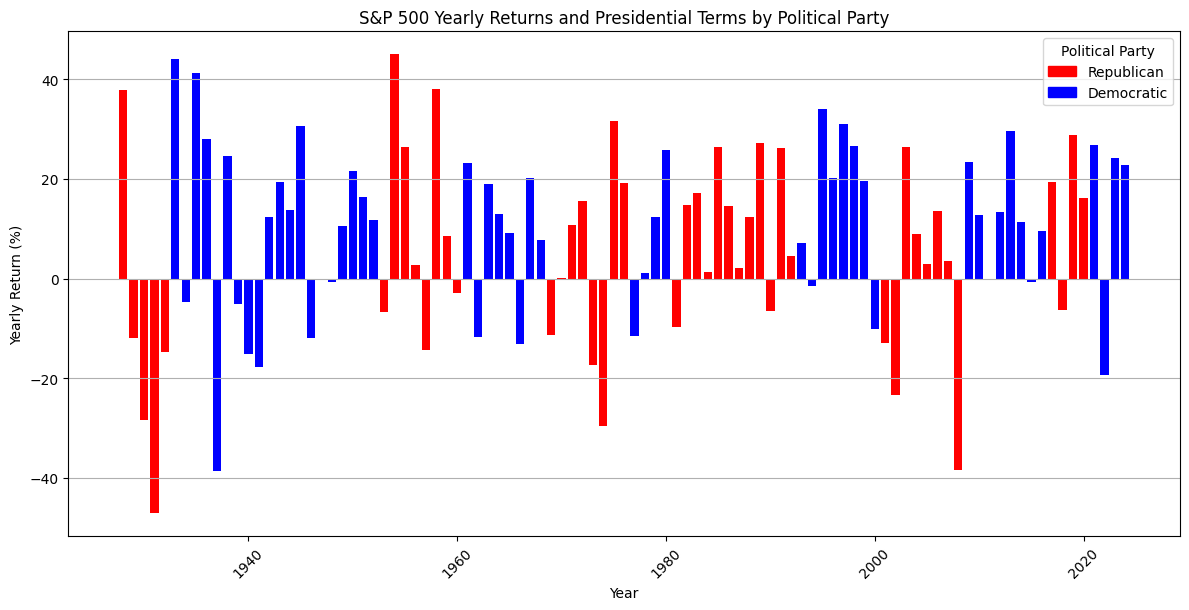

In [ ]:
#color mapping for the political parties
party_colors = {
    'Republican': 'red',
    'Democratic': 'blue'
}

plt.figure(figsize=(12, 6))

# Create a list of colors for the bars based on the party
bar_colors = merged_df['Party'].map(party_colors)

# Create bar plots
bars = plt.bar(merged_df['Year'], merged_df['Yearly Return']*100, color=bar_colors)

# titles and labels
plt.title('S&P 500 Yearly Returns and Presidential Terms by Political Party')
plt.xlabel('Year')
plt.ylabel('Yearly Return (%)')
plt.grid(axis='y')

# Legend
handles = [plt.Rectangle((0, 0), 1, 1, color=party_colors[party]) for party in party_colors]
plt.legend(handles, party_colors.keys(), title='Political Party')

plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

**<h3> Average Returns by Political Party</h3>**

This graph, which shows the average yearly returns of the S&P 500 by political party, makes it easy to see how the stock market has performed under different political leadership. Since the stock market is often seen as a measure of the economy’s health, this comparison helps understand how different parties might influence market performance.

It’s also a good way to check if the common beliefs about which political party is better for the economy actually match up with the data. For investors, this kind of information could be useful when thinking about long-term strategies, especially during election years when leadership changes might affect the market.

The chart also simplifies the relationship between politics and the economy, making it easier to talk about in class discussions or presentations. It’s a clear, visual way to show how market returns and politics might be connected, making a complex topic more understandable and engaging for everyone.

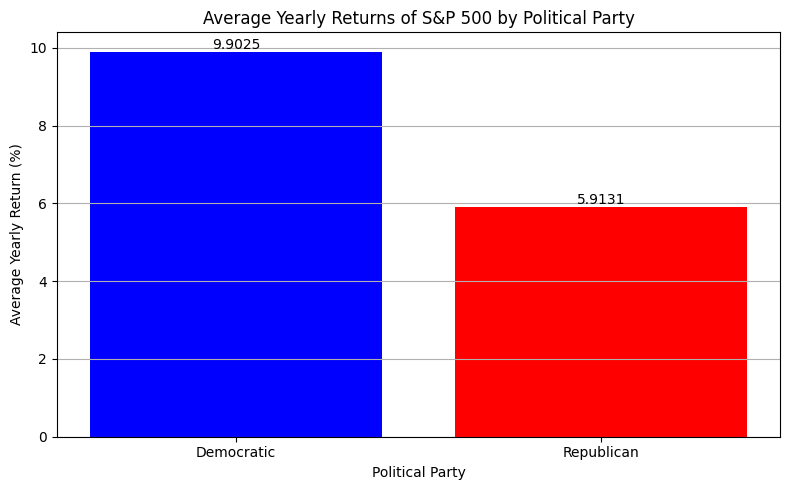

In [ ]:
# Setting a up bar chart for average returns by political party
plt.figure(figsize=(8, 5))
bars = plt.bar(average_returns['Party'], average_returns['Average Yearly Return']*100, color=['blue', 'red'])

plt.title('Average Yearly Returns of S&P 500 by Political Party')
plt.xlabel('Political Party')
plt.ylabel('Average Yearly Return (%)')
plt.grid(axis='y')

# Show average return values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### 5. Hypothesis Testing
- **Define Hypotheses:** Establish hypotheses to test the relationship between political parties and stock market performance. For example, you could test if there is a statistically significant difference in average yearly returns between different political parties.
- **Statistical Tests:** Utilize appropriate statistical tests (e.g., t-tests, ANOVA) to evaluate your hypotheses. Analyze the impact of inflation and other economic indicators on stock returns during different political administrations.

### 6. Industry Performance Analysis
- **Sector Returns:** Analyze how different industries or sectors perform under various political parties. You can break down S&P 500 data into sector-specific returns and compare them based on the political party in power during their performance periods.
- **Visualization:** Create visualizations (e.g., bar charts, box plots) to illustrate sector performance by political party.

### 7. Model Development
- **Predictive Modeling:** If appropriate, develop regression models or machine learning models to predict stock market returns based on political party and economic indicators. This could include linear regression, decision trees, or more advanced models like random forests.
- **Feature Importance:** Assess the importance of different features (political affiliation, inflation rates, etc.) in predicting stock returns.

### 8. Results Interpretation
- **Analysis of Results:** Interpret the results of your tests and models. Discuss whether the findings support your hypotheses and what implications they may have regarding the relationship between political parties and economic performance.
- **Limitations:** Address any limitations of your study, such as data availability, external economic factors, or potential biases.

### 9. Conclusion
- **Summarize Findings:** Provide a concise summary of your key findings, answering your research question regarding the influence of political parties on stock market returns.
- **Recommendations for Future Research:** Suggest areas for further exploration, such as examining the impact of specific policies or international political events.

### 10. Presentation of Findings
- **Create Visual Aids:** Prepare charts, graphs, and tables to visually communicate your findings. This could include your EDA visualizations, results from hypothesis testing, and any models developed.
- **Draft the Report:** Compile your analysis, results, and conclusions into a comprehensive report or presentation, ensuring that it is clear and engaging for your audience.

This structure will help guide your project toward a comprehensive understanding of the impact of political parties on stock market returns while considering economic indicators and industry performance. If you need assistance with any specific step, feel free to ask!